# CSDA STAC search for Evaluation Sites

Paul Montesano, PhD  
March 2026

In [83]:
#pip install contextily
#pip install matplotlib_scalebar

In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from urllib.parse import quote
import numpy as np

import sys

sys.path.append('/projects/code/csda_summaries/lib')
sys.path.append('/projects/code/geoscitools')
sys.path.append('/home/pmontesa/code/csda_summaries/lib')
sys.path.append('/home/pmontesa/code/geoscitools')

import csdalib
import staclib
import siteslib

from datetime import datetime
from multiprocessing import Pool, cpu_count
from functools import partial
from tqdm import tqdm
import importlib

## Evaluation Sites

#### Read in sites database

In [21]:
sites = siteslib.read_from_sheet(SHEET_NAME = 'Evaluation Sites', CSDA_ONLY=False)

In [22]:
BUF_KM = 3

### Create site AOIs

In [23]:
custom_geojson_dict = {
    'PICS Libya-4': '/explore/nobackup/projects/CSDA_eval/sites/map_1x3_MODISgrids_Libya4.geojson'
}

# Create GeoDataFrame
sites_gdf = siteslib.create_sites_gdf_with_aois(
    sites, 
    default_size_km=BUF_KM,
    custom_geojson_dict=custom_geojson_dict, 
    site_column='Site Name',
    lat_column='Latitude',
    lon_column='Longitude'
)

print(f"\n{sites_gdf.shape[0]} sites are being used to search for imagery.")

✓ Loaded custom geometry for PICS Libya-4

570 sites are being used to search for imagery.


#### Configure site AOIs for display

In [24]:
### Buffer MORE for sites for display
BUF_KM_ADD_FOR_DISPLAY = 25
BUF_KM_TOTAL_FOR_DISPLAY = BUF_KM_ADD_FOR_DISPLAY + BUF_KM

In [25]:
sites_gdf_buf = sites_gdf.to_crs(3857).buffer(BUF_KM_ADD_FOR_DISPLAY * 1000) # add arbitrary buffer to evaluation sites for map display
sites_gdf_buf_display = gpd.GeoDataFrame(sites_gdf.drop(columns=['geometry']), geometry=sites_gdf_buf, crs=sites_gdf_buf.crs).to_crs(4326)
sites_gdf_buf_display = sites_gdf_buf_display[~(sites_gdf_buf_display.geometry.is_empty | sites_gdf_buf_display.geometry.isna())]

# List CSDA STAC Collections

In [26]:
import requests
from IPython.display import Markdown, display

STAC_API_URL = 'https://csdap.earthdata.nasa.gov/stac'

# Get collections
response = requests.get(f'{STAC_API_URL}/collections')
data = response.json()

collections = data.get('collections', [])

# Build markdown
markdown_output = f"# CSDA STAC Collections\n\n"
markdown_output += f"**Total Collections:** {len(collections)}\n\n"
markdown_output += "| ID | Title | Description | Temporal Coverage |\n"
markdown_output += "|:---|:---|:---|:---|\n"

for collection in collections:
    col_id = collection.get('id', 'N/A')
    title = collection.get('title', 'N/A')
    description = collection.get('description', 'N/A')
    
    # Truncate and clean description
    if description and description != 'N/A':
        description = description.replace('\n', ' ').replace('\r', '')
        if len(description) > 100:
            description = description[:100] + '...'
        description = description.replace('|', '\\|')
    
    # Get temporal extent with safe None checks
    temporal_str = 'N/A'
    try:
        extent = collection.get('extent')
        if extent and isinstance(extent, dict):
            temporal = extent.get('temporal')
            if temporal and isinstance(temporal, dict):
                intervals = temporal.get('interval', [])
                if intervals and isinstance(intervals, list) and len(intervals) > 0:
                    if intervals[0] and isinstance(intervals[0], list) and len(intervals[0]) > 0:
                        start = intervals[0][0] if intervals[0][0] else 'Unknown'
                        end = intervals[0][1] if len(intervals[0]) > 1 and intervals[0][1] else 'Present'
                        
                        # Format dates nicely
                        if isinstance(start, str) and start not in ['Unknown', 'N/A']:
                            start = start.split('T')[0]
                        if isinstance(end, str) and end not in ['Present', 'N/A']:
                            end = end.split('T')[0]
                        
                        temporal_str = f"{start} to {end}"
    except Exception as e:
        # If anything goes wrong, just leave as N/A
        pass
    
    # Create collection link
    collection_url = f"{STAC_API_URL}/collections/{col_id}"
    col_id_link = f"[{col_id}]({collection_url})"
    
    markdown_output += f"| {col_id_link} | {title} | {description} | {temporal_str} |\n"

# Display in notebook
display(Markdown(markdown_output))

# Save to file
with open('stac_collections.md', 'w') as f:
    f.write(markdown_output)

print("\n✓ Saved to stac_collections.md")

# CSDA STAC Collections

**Total Collections:** 16

| ID | Title | Description | Temporal Coverage |
|:---|:---|:---|:---|
| [desis](https://csdap.earthdata.nasa.gov/stac/collections/desis) | DESIS | Teledyne Brown Engineering, Inc – DESIS | 2018-08-30 to 2024-05-25 |
| [geooptics](https://csdap.earthdata.nasa.gov/stac/collections/geooptics) | GeoOptics | geooptics | 2020-01-01 to 2021-04-30 |
| [capellaspace](https://csdap.earthdata.nasa.gov/stac/collections/capellaspace) | CapellaSpace | capellaspace | 2020-12-26 to 2026-06-03 |
| [spire](https://csdap.earthdata.nasa.gov/stac/collections/spire) | Spire | Spire | 2019-11-01 to 2025-08-09 |
| [umbra](https://csdap.earthdata.nasa.gov/stac/collections/umbra) | Umbra | Umbra Space | 2023-11-02 to 2026-06-01 |
| [iceye](https://csdap.earthdata.nasa.gov/stac/collections/iceye) | Iceye | ICEYE US | 2019-10-17 to 2026-06-03 |
| [planet](https://csdap.earthdata.nasa.gov/stac/collections/planet) | Planet | Planet | 2009-03-13 to 2026-04-13 |
| [ghgsat](https://csdap.earthdata.nasa.gov/stac/collections/ghgsat) | GHGSat | GHGSat | 2021-01-03 to 2026-04-12 |
| [pgc-earthdem](https://csdap.earthdata.nasa.gov/stac/collections/pgc-earthdem) | EarthDEM | EarthDEM | 2002-02-06 to 2024-07-01 |
| [maxar-sdx](https://csdap.earthdata.nasa.gov/stac/collections/maxar-sdx) | Maxar DEM | Maxar Technologies – Precision 3D | 2008-01-18 to 2025-05-26 |
| [planetiq](https://csdap.earthdata.nasa.gov/stac/collections/planetiq) | PlanetiQ | PlanetiQ | 2024-01-18 to 2025-03-24 |
| [tomorrow](https://csdap.earthdata.nasa.gov/stac/collections/tomorrow) | Tomorrow | The Tomorrow Companies Inc. | 2023-06-24 to 2095-12-10 |
| [airbus](https://csdap.earthdata.nasa.gov/stac/collections/airbus) | Airbus U.S.- SAR | Airbus U.S. | 2007-11-19 to 2025-12-31 |
| [maxar-legion](https://csdap.earthdata.nasa.gov/stac/collections/maxar-legion) | Maxar Legion | Maxar Technologies Inc. | 2024-09-11 to 2026-06-01 |
| [satellogic](https://csdap.earthdata.nasa.gov/stac/collections/satellogic) | Satellogic | Satellogic Inc. | 2021-02-02 to 2026-05-07 |
| [blacksky](https://csdap.earthdata.nasa.gov/stac/collections/blacksky) | BlackSky | BlackSky Technology, Inc. | 2019-05-07 to 2026-01-30 |



✓ Saved to stac_collections.md


### Create site dicts for all sites

In [27]:
site_dicts = staclib.create_site_dict_from_gdf(sites_gdf, site_name_field = 'Site Name', buffer_degrees=0.1)

# Multiprocess search across all CSDA Evaluation Sites for a vendor

### Configure search

In [28]:
COLLECTION_LIST = ['airbus']
START_OF_COMMERCIAL_ERA = '1999-01-01'
TODAY = datetime.now().strftime('%Y-%m-%d')

# START_DATE = '2010-01-01'
# END_DATE = '2025-01-21'#'2024-10-31' # last date of data used for original Satellogic eval

# START_DATE = '2025-01-21'#'2024-10-31' # last date of data used for original Satellogic eval
# END_DATE = TODAY

START_DATE = START_OF_COMMERCIAL_ERA
END_DATE = TODAY

CSDA_EVAL_SITE_ITEMS = list(site_dicts.items())

### Multiprocess SDX search across CSDA Eval sites

In [29]:
search_func = partial(staclib.stac_search_site, end_date=END_DATE, start_date=START_DATE, 
                      collections=COLLECTION_LIST
                     )
#search_func = partial(search_site, today=today, start_date='2010-01-01', collections=['maxar'])

n_processes = max(1, cpu_count() - 1)
print(f"Using {n_processes} processes to search {len(CSDA_EVAL_SITE_ITEMS)} sites\n")

# Run with progress bar
with Pool(processes=n_processes) as pool:
    results = list(tqdm(
        pool.imap(search_func, CSDA_EVAL_SITE_ITEMS),
        total=len(CSDA_EVAL_SITE_ITEMS),
        desc="Searching sites"
    ))

# Collect and report results
stac_gdf_list = []
print("\nResults by site:")
for site_name, gdf, message in results:
    print(f"  {site_name}: {message}")
    if gdf is not None:
        stac_gdf_list.append(gdf)

# Combine
if stac_gdf_list:
    stac_gdf = pd.concat(stac_gdf_list, ignore_index=True)
    print(f"\n{'='*60}")
    print(f"Total: {len(stac_gdf)} items from {stac_gdf['site_name'].nunique()} sites")
    print(f"{'='*60}")
    print("\nItems per site:")
    print(stac_gdf['site_name'].value_counts())
else:
    print("\nNo items found")
    stac_gdf = gpd.GeoDataFrame()

Using 39 processes to search 505 sites



Searching sites: 100%|██████████| 505/505 [00:07<00:00, 64.04it/s]



Results by site:
  Albuquerque: No items found
  Amazon: No items found
  Baotou: No items found
  nan: No items found
  Belo Horizonte: No items found
  Boston: No items found
  Cairo: No items found
  Cape Town: No items found
  Casablanca: No items found
  Caspian Sea: No items found
  Catania: No items found
  Crater Lake: No items found
  Cuprite: No items found
  Doldrums: No items found
  Dublin: No items found
  Gobabeb: No items found
  NISAR CR Array: No items found
  Hohhot: No items found
  King Fahd Causeway: No items found
  La Crau: No items found
  Lake Pontchartrain Causeway: Found 1 items
  London: Found 1 items
  Melbourne: No items found
  Navarre Causeway: No items found
  DLR CR Array: Found 215 items
  Old Bahia Bridge: No items found
  Phoenix: No items found
  PICS Algeria-3: No items found
  PICS Libya-1: No items found
  PICS Libya-4: No items found
  Piedmont: No items found
  Railroad Valley: No items found
  Rio Gallegos: No items found
  RCRA: Found 39 i

## SDX acquisitions

In [30]:
stac_gdf = stac_gdf.drop(columns=[col for col in stac_gdf.columns if 'asset' in col])

In [31]:
stac_gdf.shape

(402, 45)

# Plot maps of sites and their acqs (static)

## Overview map of STAC collections at evaluation sites

402 SAR airbus acquisitions on SDX


/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/contextily/tile.py:581: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 16).
  warnings.warn(msg)


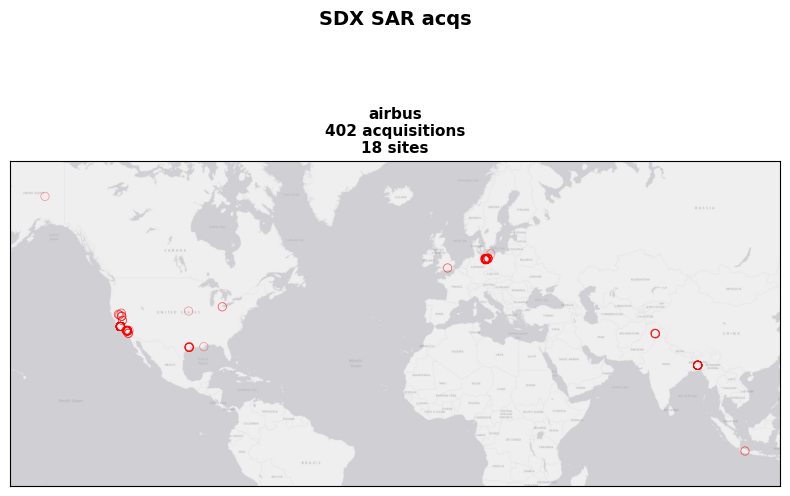

In [32]:
# Just SAR : Airbus data in SDX at our sites is only SAR right now
PROD_SEARCH_STR = 'SAR'
stac_gdf_sub = stac_gdf[stac_gdf['id'].str.contains(PROD_SEARCH_STR, na=False)]
print(f"{stac_gdf_sub.shape[0]} {PROD_SEARCH_STR} {COLLECTION_LIST[0]} acquisitions on SDX")

fig = staclib.plot_collections_map(stac_gdf_sub, show_stats=True, collection_field='collection', suptitle=f"SDX {PROD_SEARCH_STR} acqs")
plt.show()

/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/contextily/tile.py:581: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 16).
  warnings.warn(msg)


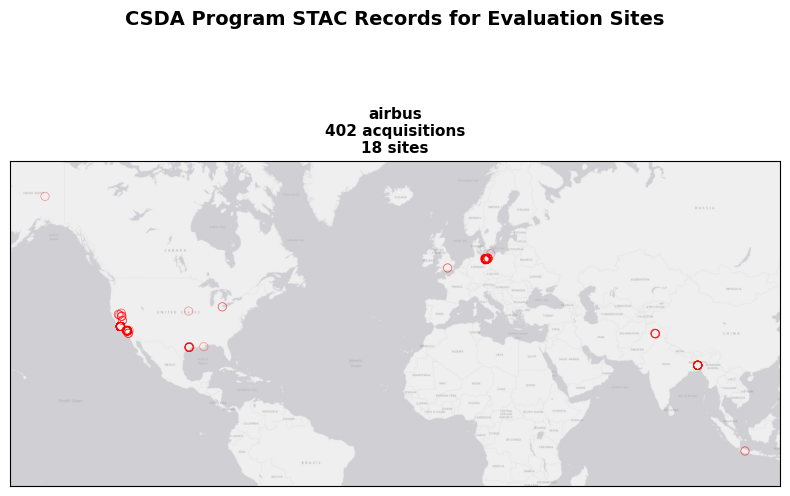

In [33]:
# All Airbus data in SDX at our sites
fig = staclib.plot_collections_map(stac_gdf, show_stats=True)
plt.show()

### Plot site maps for acquisitions

/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


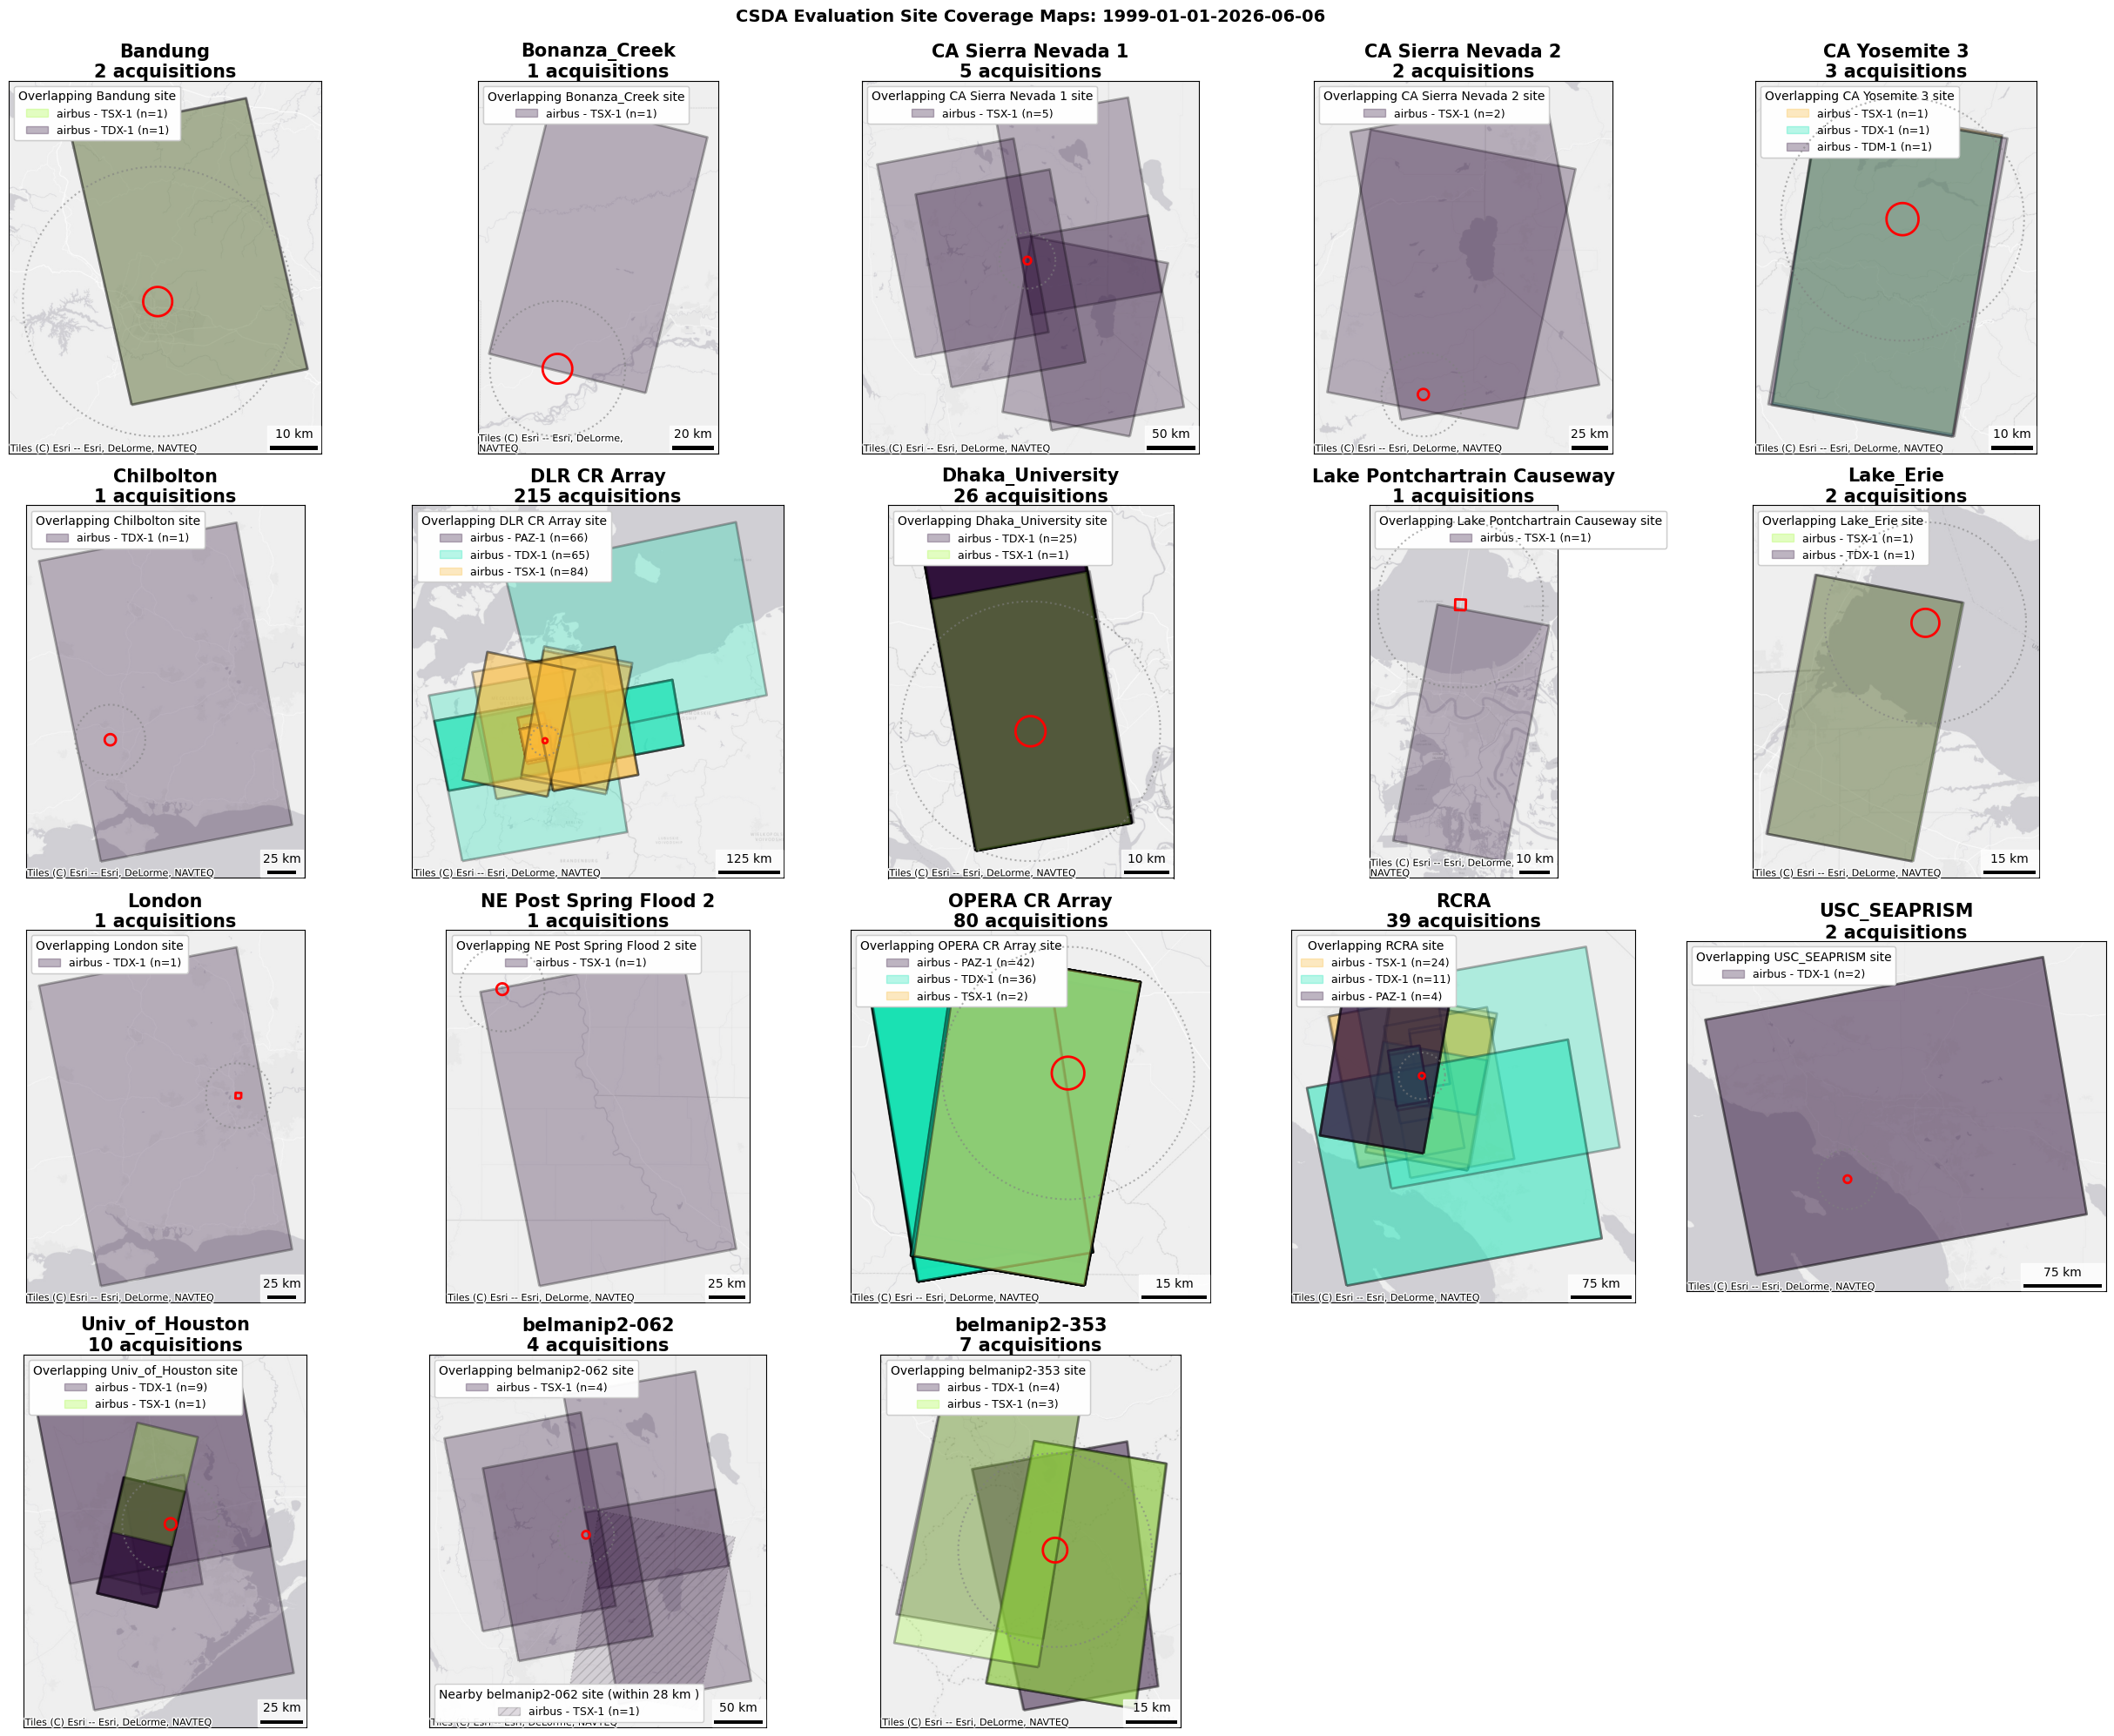

In [34]:
# Define gdf to plot
gdf_to_plot = stac_gdf

# Define sites to plot
sites_to_plot = sorted([site for site in gdf_to_plot.site_name.unique() if site != 'Not CSDA Eval Site'])

# Create grid
n_sites = len(sites_to_plot)
n_cols = 5
n_rows = int(np.ceil(n_sites / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols,5 * n_rows))

# Flatten axes
if n_sites == 1:
    axes = [axes]
else:
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

# Plot each site
for idx, site_name in enumerate(sites_to_plot):
    csdalib.plot_site_coverage(site_name, 
                      gdf_to_plot, 
                      sites_gdf, 
                      BUF_KM, 
                       BUF_KM_TOTAL_FOR_DISPLAY,
                      sites_buf_gdf=sites_gdf_buf_display,
                      site_name_field = 'site_name',
                               
                        # Satellogic
                        id_field = 'id', 
                        affiliation_field = 'collection',
                        constellation_field = 'platform',
                               
                      ax=axes[idx])  # Pass the axis here

# Hide unused subplots
for idx in range(n_sites, len(axes)):
    axes[idx].axis('off')

# Add main title
plt.suptitle(f"CSDA Evaluation Site Coverage Maps: {START_DATE}-{END_DATE}", fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

## Heatmaps provides info on amount of overlap at a site

#### static, all sites for each collection

Calculating global count range...
Global count range: 1 - 215


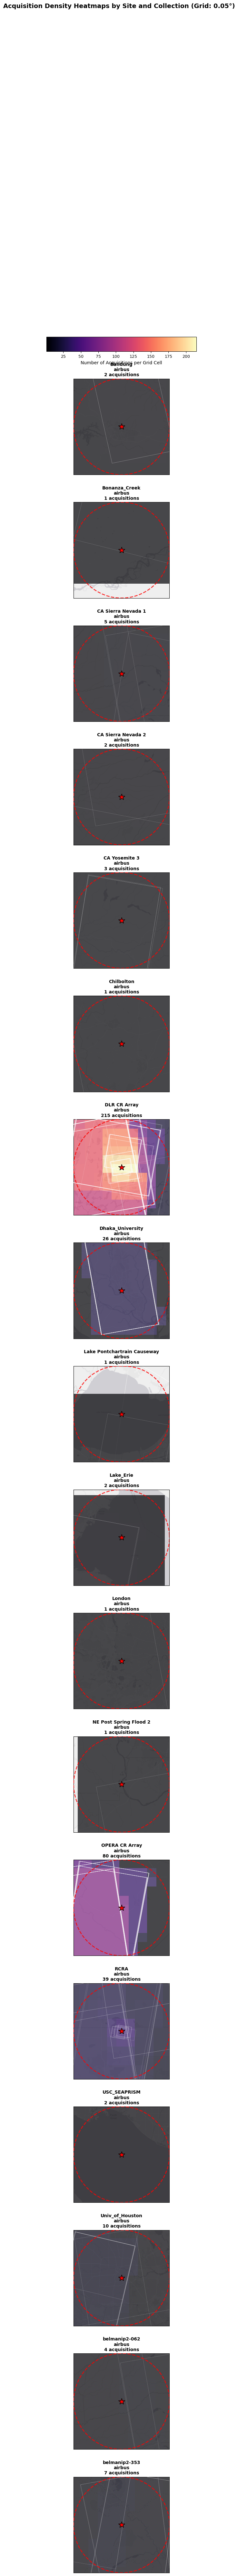

In [35]:
# Use it
all_grids, fig = staclib.create_acquisition_heatmap_multi(
    stac_gdf,
    sites_gdf,
    sites_gdf_buf_display,
    site_name_field='site_name',
    site_name_field_sites='Site Name',
    # collections=['planet', 'satellogic'],
    # sites=['PICS Libya-4', 'Casablanca'],
    collections=COLLECTION_LIST,
    sites=None,
    grid_size=0.05,
    cmap='magma'
)

plt.show()

#### interactive for 1 site, collection

In [36]:
m, grid_gdf = staclib.create_interactive_heatmap(
    stac_gdf,
    collection_name=COLLECTION_LIST[0],
    grid_size=0.01,
    cmap='magma',
    site_name='PICS Libya-4'
)

# m.save('libya4_satellogic_heatmap.html')
m

Creating heatmap for 0 acquisitions


ValueError: arange: cannot compute length